<a href="https://colab.research.google.com/github/kajallsingh/CreditCardFraud/blob/main/CreditCardFraudDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q xgboost lightgbm imbalanced-learn

Importing Libraries

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, classification_report)

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
import lightgbm as lgb

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

import warnings
warnings.filterwarnings('ignore')

Load the dataset

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"kaajalllsingh","key":"1e307bb19510464402020525c6918396"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d mlg-ulb/creditcardfraud

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
  0% 0.00/66.0M [00:00<?, ?B/s]
100% 66.0M/66.0M [00:00<00:00, 1.25GB/s]


In [5]:
!unzip creditcardfraud.zip

Archive:  creditcardfraud.zip
  inflating: creditcard.csv          


In [6]:
df=pd.read_csv('creditcard.csv')
print("Shape: ",df.shape)
df.head()

Shape:  (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Data Processing

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [8]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [9]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [10]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


Featuring

In [11]:
X= df.drop('Class', axis=1)
y= df['Class']

Train- Test- Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print("Shape of X_train: ", X_train.shape)
print("Shape of X_test: ", X_test.shape)

Shape of X_train:  (227845, 30)
Shape of X_test:  (56962, 30)


Evaluation

In [13]:
def evaluate_model(model, X_test, y_test, name='Model', plot_roc=True):

    # Predictions
    y_pred = model.predict(X_test)

    # Probabilities for ROC/AUC (some models use predict_proba, others decision_function)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:,1]
    elif hasattr(model, "decision_function"):
        y_proba = model.decision_function(X_test)
    else:
        y_proba = y_pred  # fallback if probabilities not available

    # Metrics
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    roc  = roc_auc_score(y_test, y_proba)

    # Print results
    print(f"\n=== {name} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 score : {f1:.4f}")
    print(f"ROC AUC  : {roc:.4f}")
    print("\nClassification report:\n", classification_report(y_test, y_pred, zero_division=0))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.show()

    # ROC Curve
    if plot_roc:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.figure(figsize=(6,4))
        plt.plot(fpr, tpr, label=f'{name} (AUC={roc:.4f})')
        plt.plot([0,1], [0,1], '--', color='gray')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'{name} ROC Curve')
        plt.legend()
        plt.show()

    # Return results in dictionary for comparison table
    return {
        'name': name,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'roc_auc': roc
    }

Pipelines with SMOTE


=== Random Forest+SMOTE ===
Accuracy : 0.9995
Precision: 0.8469
Recall   : 0.8469
F1 score : 0.8469
ROC AUC  : 0.9661

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.85      0.85        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962



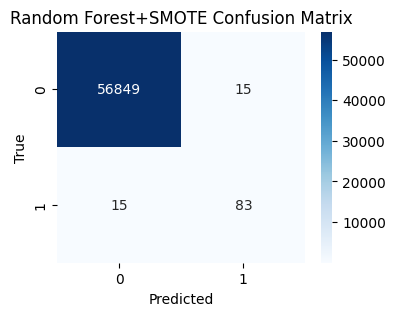

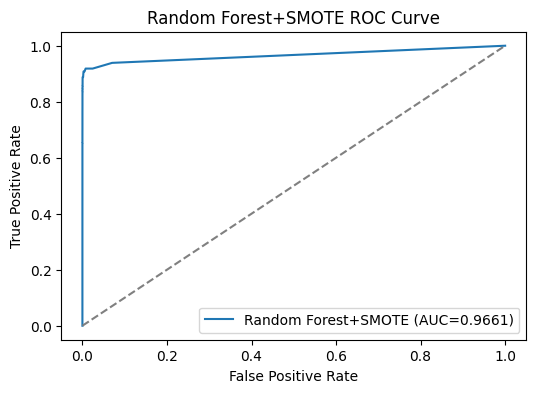


=== Gradient Boosting+SMOTE ===
Accuracy : 0.9985
Precision: 0.5437
Recall   : 0.8878
F1 score : 0.6744
ROC AUC  : 0.9697

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.54      0.89      0.67        98

    accuracy                           1.00     56962
   macro avg       0.77      0.94      0.84     56962
weighted avg       1.00      1.00      1.00     56962



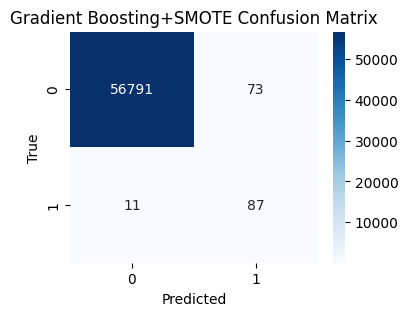

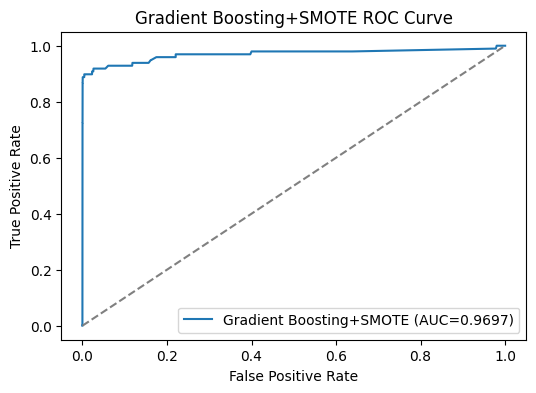


=== XGBoost+SMOTE ===
Accuracy : 0.9993
Precision: 0.7830
Recall   : 0.8469
F1 score : 0.8137
ROC AUC  : 0.9777

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.78      0.85      0.81        98

    accuracy                           1.00     56962
   macro avg       0.89      0.92      0.91     56962
weighted avg       1.00      1.00      1.00     56962



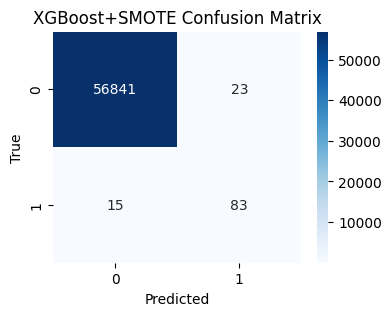

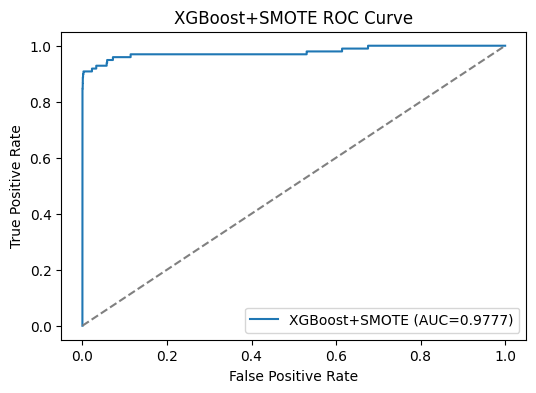

[LightGBM] [Info] Number of positive: 22745, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.089593 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 250196, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.090909 -> initscore=-2.302589
[LightGBM] [Info] Start training from score -2.302589

=== LightGBM+SMOTE ===
Accuracy : 0.9990
Precision: 0.6641
Recall   : 0.8673
F1 score : 0.7522
ROC AUC  : 0.9791

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.66      0.87      0.75        98

    accuracy                           1.00     56962
   macro avg       0.83      0.93      0.88     56962
weighted avg       1.00      1.00      1.00     56962



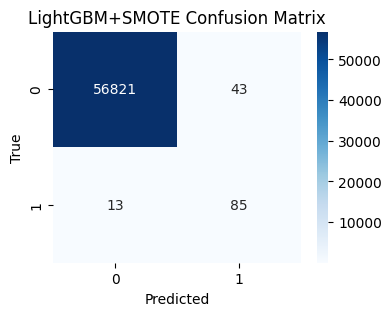

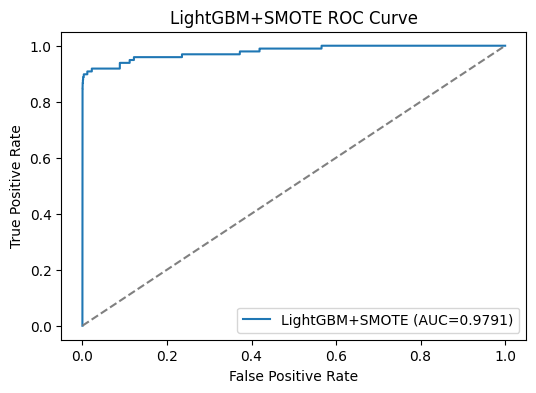

In [21]:
# Random Forest
rf_pipeline = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42, sampling_strategy=0.1)),
    ('model', RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=50))
])
rf_pipeline.fit(X_train, y_train)
res_rf = evaluate_model(rf_pipeline, X_test, y_test, name='Random Forest+SMOTE')

# Gradient Boosting
gb_pipeline = ImbPipeline(steps= [
    ('smote', SMOTE(random_state=42, sampling_strategy=0.1)),
    ('model', GradientBoostingClassifier(random_state=42, n_estimators=50))
])
gb_pipeline.fit(X_train, y_train)
res_gb = evaluate_model(gb_pipeline, X_test, y_test, name='Gradient Boosting+SMOTE')

# XGBoost
xgb_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42, sampling_strategy=0.1)),
    ('model', xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', n_estimators=50, random_state=42, n_jobs=-1))
])
xgb_pipeline.fit(X_train, y_train)
res_xgb = evaluate_model(xgb_pipeline, X_test, y_test, name='XGBoost+SMOTE')

# LightGBM
lgb_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42, sampling_strategy=0.1)),
    ('model', lgb.LGBMClassifier(random_state=42, n_jobs=-1, n_estimators=50))
])
lgb_pipeline.fit(X_train, y_train)
res_lgb = evaluate_model(lgb_pipeline, X_test, y_test, name='LightGBM+SMOTE')

Random Forest Hyperparameter Tuning

In [26]:
max_sample=100_100
if(len(X_train)>max_sample):
  sss= StratifiedShuffleSplit(n_splits=1, test_size=max_sample , random_state=42)
  idx_train, _= next(sss.split(X_train, y_train))
  X_train_sub= X_train.iloc[idx_train]
  y_train_sub= y_train.iloc[idx_train]
else:
    X_train_sub= X_train.copy()
    y_train_sub= y_train.copy()

print(f"RandomizedSEarchedCV will train on {len(X_train_sub)} rows fpr speed")

param_dist = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}
rf= RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced_subsample')
random_search = RandomizedSearchCV(rf, param_distributions=param_dist, n_iter=5, cv=3, scoring='f1' , random_state=42, n_jobs=-1, verbose=2)
random_search.fit(X_train_sub, y_train_sub)
best_params = random_search.best_params_
print("Best Hyperparameters:", best_params)
print("Best Score:", random_search.best_score_)

RandomizedSEarchedCV will train on 27645 rows fpr speed
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best Hyperparameters: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': None}
Best Score: 0.8248690377722636


Collect and Compare Result

In [28]:
results = [res_rf, res_gb, res_xgb, res_lgb]
df_results = pd.DataFrame(results).sort_values('roc_auc', ascending=False).reset_index(drop=True)
display(df_results)

,name,accuracy,precision,recall,f1,roc_auc
0,LightGBM+SMOTE,0.999017,0.664062,0.867347,0.752212,0.979103
1,XGBoost+SMOTE,0.999333,0.783019,0.846939,0.813725,0.977688
2,Gradient Boosting+SMOTE,0.998525,0.543750,0.887755,0.674419,0.969662
3,Random Forest+SMOTE,0.999473,0.846939,0.846939,0.846939,0.966122


Evaluating the model

===== Classification Report =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.79      0.76      0.77        98

    accuracy                           1.00     56962
   macro avg       0.89      0.88      0.89     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy: 0.9992
F1 Score: 0.7708
Precision: 0.7872
Recall: 0.7551


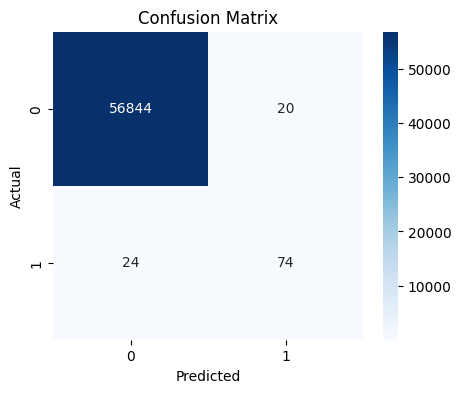

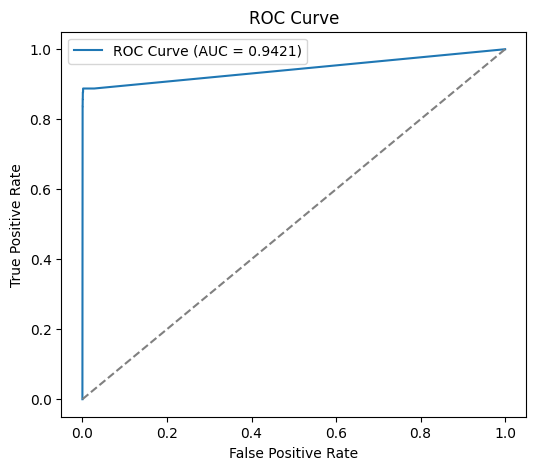

In [29]:

#  Predict on test set
y_pred = random_search.predict(X_test)  # or best_rf.predict(X_test) if you saved the model
y_proba = random_search.predict_proba(X_test)[:,1]  # probability for ROC curve

# Classification metrics
print("===== Classification Report =====")
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")


# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ROC Curve & AUC
roc_auc = roc_auc_score(y_test, y_proba)
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


Collecting results

In [31]:
results = {}

# Random Forest (Tuned)
y_pred_rf = final_pipeline.predict(X_test)
results['RandomForest_Tuned'] = {
    'F1': f1_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'Accuracy': accuracy_score(y_test, y_pred_rf)
}

# Gradient Boosting
y_pred_gb = gb_pipeline.predict(X_test)
results['GradientBoosting'] = {
    'F1': f1_score(y_test, y_pred_gb),
    'Precision': precision_score(y_test, y_pred_gb),
    'Recall': recall_score(y_test, y_pred_gb),
    'Accuracy': accuracy_score(y_test, y_pred_gb)
}

# XGBoost
y_pred_xgb = xgb_pipeline.predict(X_test)
results['XGBoost'] = {
    'F1': f1_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb),
    'Recall': recall_score(y_test, y_pred_xgb),
    'Accuracy': accuracy_score(y_test, y_pred_xgb)
}

# LightGBM
y_pred_lgb = lgb_pipeline.predict(X_test)
results['LightGBM'] = {
    'F1': f1_score(y_test, y_pred_lgb),
    'Precision': precision_score(y_test, y_pred_lgb),
    'Recall': recall_score(y_test, y_pred_lgb),
    'Accuracy': accuracy_score(y_test, y_pred_lgb)
}

# Convert to DataFrame for comparison
import pandas as pd
results_df = pd.DataFrame(results).T
print(results_df.sort_values(by='F1', ascending=False))

                          F1  Precision    Recall  Accuracy
RandomForest_Tuned  0.815920   0.796117  0.836735  0.999350
XGBoost             0.813725   0.783019  0.846939  0.999333
LightGBM            0.752212   0.664062  0.867347  0.999017
GradientBoosting    0.674419   0.543750  0.887755  0.998525


Saving the model

In [34]:
import joblib
joblib.dump(random_search.best_estimator_, 'CreditCardModel.joblib')
model= joblib.load('CreditCardModel.joblib')

Testing

In [35]:
new_data= X_test.iloc[0:1]
pred= model.predict(new_data)
print("FRAUD" if pred[0]==1 else "NOT FRAUD")

NOT FRAUD


Some Features

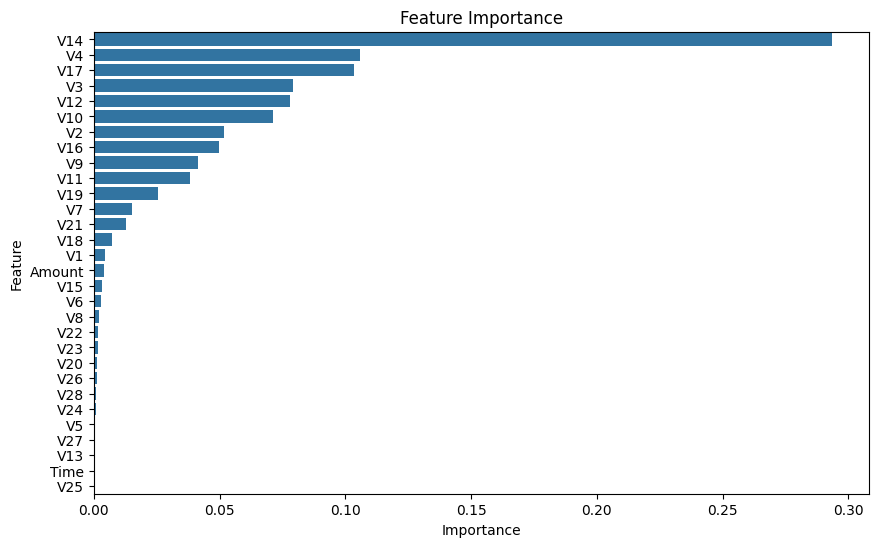

In [36]:
importances = random_search.best_estimator_.feature_importances_
feat_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_df)
plt.title("Feature Importance")
plt.show()